In [16]:
import pandas as pd
import numpy as np

In [17]:
df=pd.read_csv('/content/IMDB Dataset.csv')

In [18]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [19]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [20]:
df.shape

(50000, 2)

In [21]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [23]:
df.duplicated().sum()

np.int64(418)

In [24]:
df["review"].duplicated().sum()

np.int64(418)

In [25]:
df=df.drop_duplicates()

In [26]:
df.shape


(49582, 2)

In [27]:
df["sentiment"].value_counts()

,count
sentiment,
positive,24884
negative,24698


In [28]:
df = df.copy()

df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

In [29]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [30]:
df["sentiment"].unique()

array([1, 0])

In [31]:
df["sentiment"].value_counts()

,count
sentiment,
1,24884
0,24698


In [32]:
import re
def clean_text(text):
    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Convert to lowercase
    text = text.lower()

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["review"] = df["review"].apply(clean_text)

In [33]:
X=df["review"]
y=df["sentiment"]
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)


In [34]:
X_train.head()


,review
34797,i am one of jehovah's witnesses and i also wor...
17295,amongst the standard one liner type action fil...
9424,realty television crew are assigned to cover a...
21987,the funniest scene of this movie is probably w...
10839,there have been far too few mainstream films s...


In [35]:
X_train.shape

(39665,)

In [36]:
y_train.shape

(39665,)

In [37]:
y_train.head()

,sentiment
34797,1
17295,1
9424,0
21987,0
10839,1


In [38]:
print(X_train.iloc[0])

i am one of jehovah's witnesses and i also work in an acute care medical facility. over the years i have seen people die from hemolytic reactions to blood transfusions, have attended numerous conferences on blood born pathogens, and have seen several patients become seriously ill from pathogens induced by transfused blood. i have also heard several jehovah's witnesses being told that they will die if they refuse blood and after 26 years in the field i have never actually seen it happen, leaving the question, "is it really unreasonable to refuse blood transfusions or is the community at large benefiting from the battle on this issue?" the issue for jehovah's witnesses is a moral one. "you must abstain from blood" is not an ambiguous statement. thank you for this movie and allowing comments on it.


In [39]:
print(X_train.iloc[1])

amongst the standard one liner type action films, where acting and logic are checked at the door, this movie is at the top of the class. if the person in charge of casting were to have put "good" actors in this flick, it would have been worse(excepting richard dawson who actually did act well, if you can call playing yourself "acting"). i love this movie! the running man is in all likelihood god's gift to man(okay maybe just men). definitely the most quotable movie of our time so i'll part you with my favorite line: "it's all part of life's rich pattern brenda, and you better f*****g get used to it." ahh, more people have been called "brenda" for the sake of quoting this film than i can possibly imagine.


### Hugging Face Transformers

In [40]:
!pip install transformers datasets accelerate

In [41]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification


In [42]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

In [43]:
text=X_train.iloc[0]
token=tokenizer.tokenize(text)
print(token)

['i', 'am', 'one', 'of', 'je', '##ho', '##vah', "'", 's', 'witnesses', 'and', 'i', 'also', 'work', 'in', 'an', 'acute', 'care', 'medical', 'facility', '.', 'over', 'the', 'years', 'i', 'have', 'seen', 'people', 'die', 'from', 'hem', '##ol', '##ytic', 'reactions', 'to', 'blood', 'trans', '##fusion', '##s', ',', 'have', 'attended', 'numerous', 'conferences', 'on', 'blood', 'born', 'pathogen', '##s', ',', 'and', 'have', 'seen', 'several', 'patients', 'become', 'seriously', 'ill', 'from', 'pathogen', '##s', 'induced', 'by', 'trans', '##fus', '##ed', 'blood', '.', 'i', 'have', 'also', 'heard', 'several', 'je', '##ho', '##vah', "'", 's', 'witnesses', 'being', 'told', 'that', 'they', 'will', 'die', 'if', 'they', 'refuse', 'blood', 'and', 'after', '26', 'years', 'in', 'the', 'field', 'i', 'have', 'never', 'actually', 'seen', 'it', 'happen', ',', 'leaving', 'the', 'question', ',', '"', 'is', 'it', 'really', 'unreasonable', 'to', 'refuse', 'blood', 'trans', '##fusion', '##s', 'or', 'is', 'the', 

In [44]:
encoded = tokenizer(
    X_train.iloc[0],
    padding="max_length",
    truncation=True,
    max_length=256
)

In [45]:
print(len(encoded["input_ids"]))
print(len(encoded["attention_mask"]))

256
256


In [46]:
print(encoded["input_ids"][:30])

[101, 1045, 2572, 2028, 1997, 15333, 6806, 21927, 1005, 1055, 9390, 1998, 1045, 2036, 2147, 1999, 2019, 11325, 2729, 2966, 4322, 1012, 2058, 1996, 2086, 1045, 2031, 2464, 2111, 3280]


In [47]:
print(encoded["attention_mask"][:30])

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [48]:
print(tokenizer.convert_ids_to_tokens(encoded["input_ids"][:30]))

['[CLS]', 'i', 'am', 'one', 'of', 'je', '##ho', '##vah', "'", 's', 'witnesses', 'and', 'i', 'also', 'work', 'in', 'an', 'acute', 'care', 'medical', 'facility', '.', 'over', 'the', 'years', 'i', 'have', 'seen', 'people', 'die']


### TOknaization of fully dataset

In [49]:
train_encodings = tokenizer(
    X_train.tolist(),
    padding="max_length",
    truncation=True,
    max_length=256
)

val_encodings = tokenizer(
    X_val.tolist(),
    padding="max_length",
    truncation=True,
    max_length=256
)

test_encodings = tokenizer(
    X_test.tolist(),
    padding="max_length",
    truncation=True,
    max_length=256
)

In [50]:
print(len(train_encodings["input_ids"]))
print(len(val_encodings["input_ids"]))
print(len(test_encodings["input_ids"]))

39665
4958
4959


### Create the Dataset

In [51]:
from torch.utils.data import Dataset, DataLoader
import torch

class IMDbDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return item

In [52]:
train_dataset = IMDbDataset(train_encodings, y_train)
val_dataset = IMDbDataset(val_encodings, y_val)
test_dataset = IMDbDataset(test_encodings, y_test)

In [53]:
print(train_dataset[0])

{'input_ids': tensor([  101,  1045,  2572,  2028,  1997, 15333,  6806, 21927,  1005,  1055,
         9390,  1998,  1045,  2036,  2147,  1999,  2019, 11325,  2729,  2966,
         4322,  1012,  2058,  1996,  2086,  1045,  2031,  2464,  2111,  3280,
         2013, 19610,  4747, 21252,  9597,  2000,  2668,  9099, 20523,  2015,
         1010,  2031,  3230,  3365,  9281,  2006,  2668,  2141, 26835,  2015,
         1010,  1998,  2031,  2464,  2195,  5022,  2468,  5667,  5665,  2013,
        26835,  2015, 10572,  2011,  9099, 25608,  2098,  2668,  1012,  1045,
         2031,  2036,  2657,  2195, 15333,  6806, 21927,  1005,  1055,  9390,
         2108,  2409,  2008,  2027,  2097,  3280,  2065,  2027, 10214,  2668,
         1998,  2044,  2656,  2086,  1999,  1996,  2492,  1045,  2031,  2196,
         2941,  2464,  2009,  4148,  1010,  2975,  1996,  3160,  1010,  1000,
         2003,  2009,  2428, 29205,  2000, 10214,  2668,  9099, 20523,  2015,
         2030,  2003,  1996,  2451,  2012,  2312, 

In [54]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16
)

In [55]:
batch = next(iter(train_loader))

print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

torch.Size([16, 256])
torch.Size([16, 256])
torch.Size([16])


In [56]:
model_name = "distilbert-base-uncased"

In [57]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [58]:
print(model)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [59]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [60]:
model = model.to(device)

In [61]:
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

In [62]:
loss_fn = torch.nn.CrossEntropyLoss()

In [63]:
model.train()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [64]:
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
labels = batch["labels"].to(device)

outputs = model(
    input_ids=input_ids,
    attention_mask=attention_mask,
    labels=labels
)

print(outputs.loss)

tensor(0.6918, device='cuda:0', grad_fn=<NllLossBackward0>)


In [65]:
from tqdm.auto import tqdm

epochs = 1

for epoch in range(epochs):

    model.train()
    total_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for batch in progress_bar:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    average_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1} Average Loss: {average_loss:.4f}")

Epoch 1:   0%|          | 0/2480 [00:00<?, ?it/s]

Epoch 1 Average Loss: 0.2597


In [66]:
model.eval()

correct = 0
total = 0
val_loss = 0

with torch.no_grad():

    for batch in val_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        val_loss += loss.item()

        predictions = torch.argmax(logits, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

val_accuracy = correct / total
average_val_loss = val_loss / len(val_loader)

print(f"Validation Loss: {average_val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Validation Loss: 0.2161
Validation Accuracy: 0.9181
Validation Accuracy: 91.81%


In [67]:
model.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        test_loss += outputs.loss.item()

        predictions = torch.argmax(outputs.logits, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
average_test_loss = test_loss / len(test_loader)

print(f"Test Loss: {average_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.2187
Test Accuracy: 0.9143
Test Accuracy: 91.43%


In [68]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(
    all_labels,
    all_predictions,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.90      0.93      0.92      2470
    Positive       0.93      0.90      0.91      2489

    accuracy                           0.91      4959
   macro avg       0.91      0.91      0.91      4959
weighted avg       0.91      0.91      0.91      4959



[[2300  170]
 [ 255 2234]]


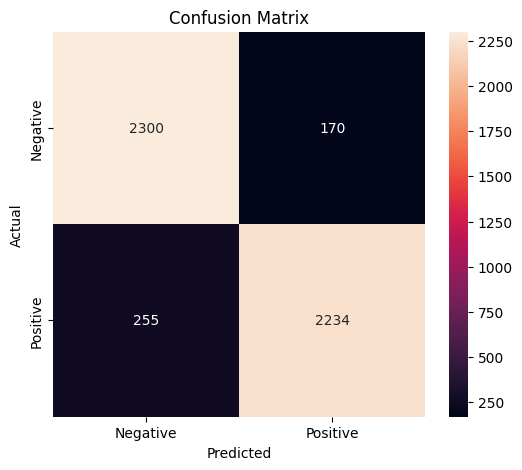

In [69]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_predictions)

print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [70]:
model.save_pretrained("./imdb-distilbert")
tokenizer.save_pretrained("./imdb-distilbert")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./imdb-distilbert/tokenizer_config.json', './imdb-distilbert/tokenizer.json')

In [74]:
import torch

def predict_sentiment(text):

    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=1)

    prediction = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0][prediction].item()

    sentiment = "Positive" if prediction == 1 else "Negative"

    return sentiment, confidence

In [75]:
print(predict_sentiment(
    "This movie was absolutely fantastic and I really enjoyed it!"
))

('Positive', 0.9964476823806763)


In [76]:
print(predict_sentiment(
    "This movie was boring, disappointing, and a waste of time."
))

('Negative', 0.9976578950881958)


In [77]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "./imdb-distilbert"

tokenizer = AutoTokenizer.from_pretrained(model_path)

model = AutoModelForSequenceClassification.from_pretrained(model_path)

model = model.to(device)
model.eval()

print("Model loaded successfully!")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded successfully!


In [78]:
text = "This movie was amazing. I really enjoyed it!"

sentiment, confidence = predict_sentiment(text)

print("Sentiment:", sentiment)
print("Confidence:", f"{confidence * 100:.2f}%")

Sentiment: Positive
Confidence: 99.60%


In [80]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 44.2 MB/s eta 0:00:00


In [81]:
import streamlit as st
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# -----------------------------
# Load model
# -----------------------------
MODEL_PATH = "./imdb-distilbert"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()


# -----------------------------
# Prediction function
# -----------------------------
def predict_sentiment(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=1)

    prediction = torch.argmax(probabilities, dim=1).item()
    confidence = probabilities[0][prediction].item()

    sentiment = "Positive" if prediction == 1 else "Negative"

    return sentiment, confidence


# -----------------------------
# Streamlit UI
# -----------------------------
st.title("🎬 IMDb Movie Review Sentiment Analysis")

st.write(
    "Enter a movie review and the fine-tuned DistilBERT model "
    "will predict its sentiment."
)

review = st.text_area(
    "Enter your movie review:",
    placeholder="Example: This movie was fantastic and I really enjoyed it!"
)

if st.button("Predict Sentiment"):

    if review.strip():

        sentiment, confidence = predict_sentiment(review)

        st.subheader("Prediction")

        st.write(f"**Sentiment:** {sentiment}")
        st.write(f"**Confidence:** {confidence * 100:.2f}%")

    else:

        st.warning("Please enter a movie review.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

2026-09-16 14:13:07.846 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-16 14:13:08.214 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-16 14:13:08.216 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-16 14:13:08.220 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-16 14:13:08.224 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-16 14:13:08.227 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-16 14:13:08.232 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-16 14:13:08.233 Thread 'MainThread': mi

In [82]:
!pip install -U huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 14.7 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.29.0
    Uninstalling huggingface_hub-1.29.0:
      Successfully uninstalled huggingface_hub-1.29.0


In [1]:
from huggingface_hub import login

login()

In [2]:
from huggingface_hub import HfApi

api = HfApi()

api.create_repo(
    repo_id="alishbokha/imdb-distilbert",
    repo_type="model",
    exist_ok=True
)

api.upload_folder(
    folder_path="./imdb-distilbert",
    repo_id="alishbokha/imdb-distilbert",
    repo_type="model"
)

CommitInfo(commit_url='https://huggingface.co/alishbokha/imdb-distilbert/commit/5f3bacc6f84180d92650e41273494df5d926cd7c', commit_message='Upload folder using huggingface_hub', commit_description='', oid='5f3bacc6f84180d92650e41273494df5d926cd7c', pr_url=None, repo_url=RepoUrl('https://huggingface.co/alishbokha/imdb-distilbert', endpoint='https://huggingface.co', repo_type='model', repo_id='alishbokha/imdb-distilbert'), pr_revision=None, pr_num=None)